In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astrolab import imaging as im
from astrolab import photometry as phot

In [ ]:
#im.sort_astrophotos(base_dir="./20250404/", object_prefix="phot_HR1411_HR1412_p1s")

File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT


C:\Users\abhim\miniconda3\envs\ast1080\lib\site-packages\astrolab\imaging.py:191: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()            # TODO: Incorporate figsize somehow?


File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File extension detected as FIT
File ext


KeyboardInterrupt



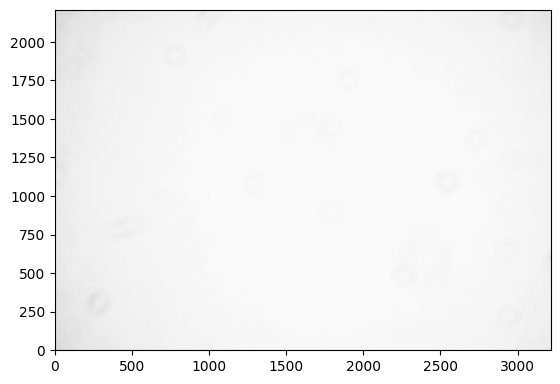

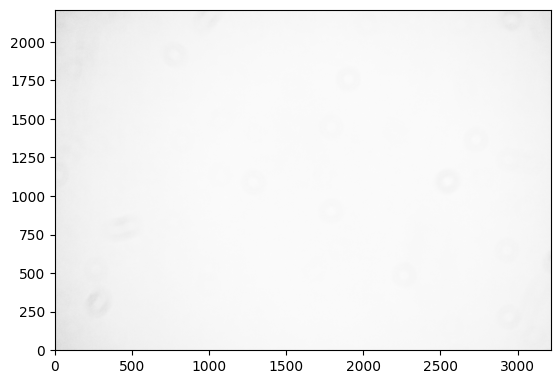

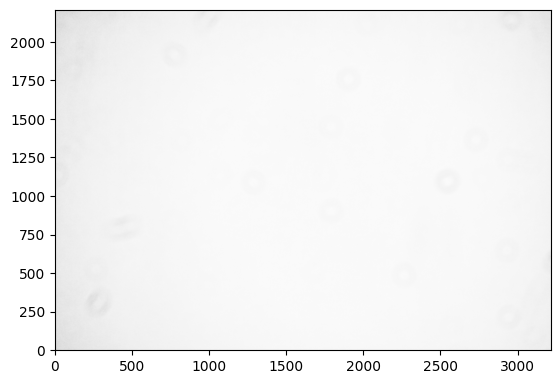

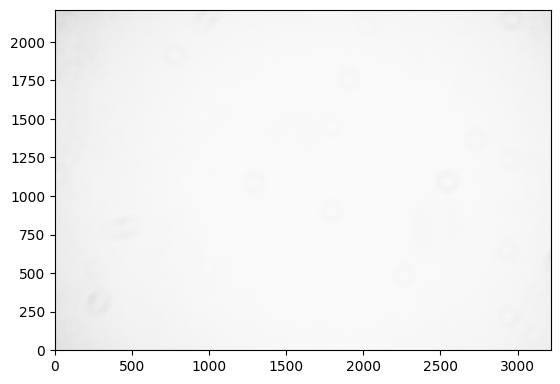

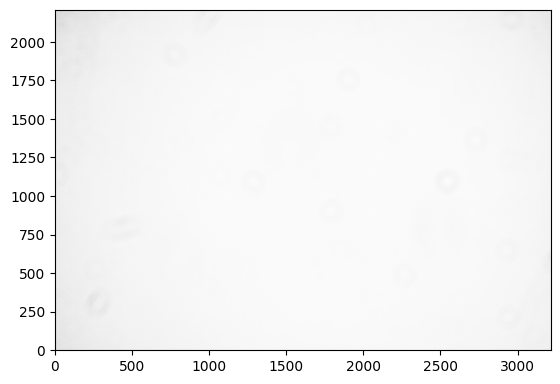

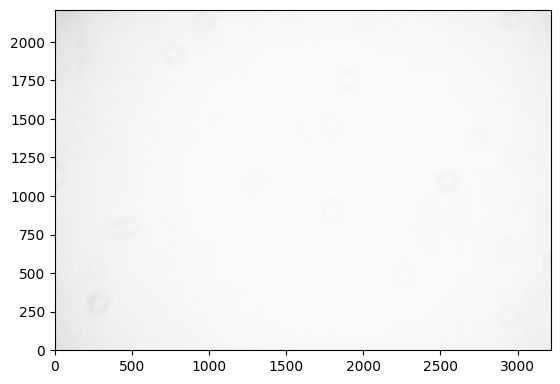

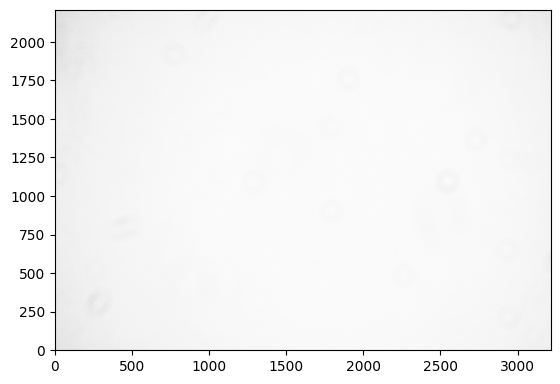

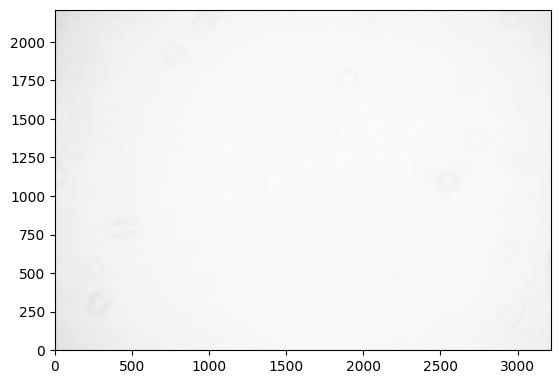

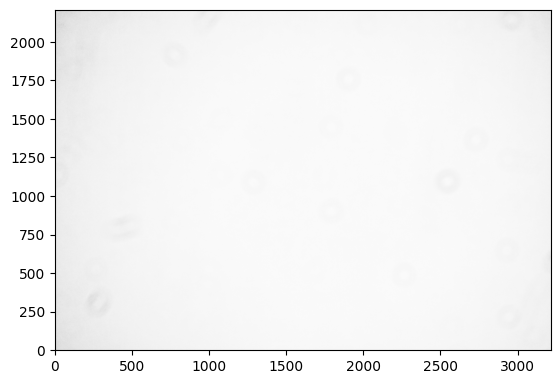

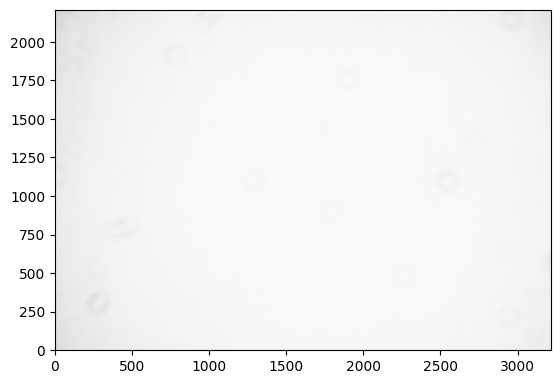

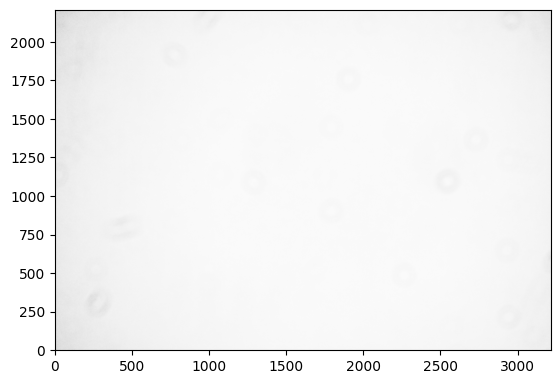

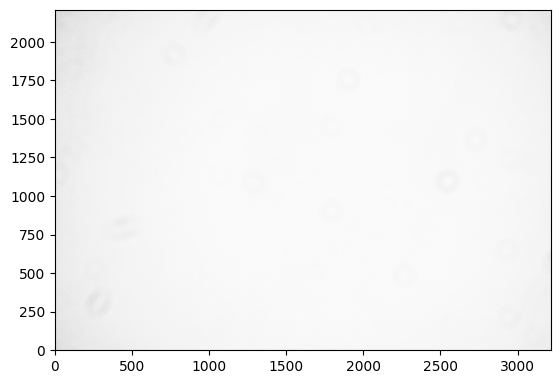

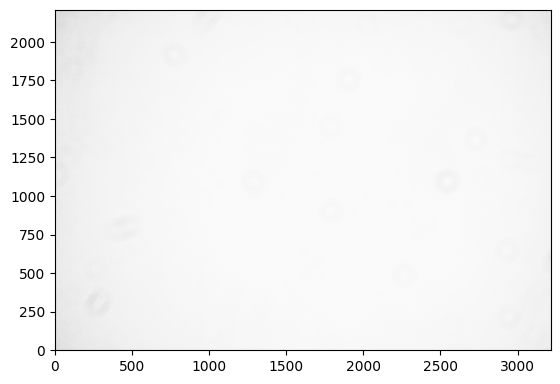

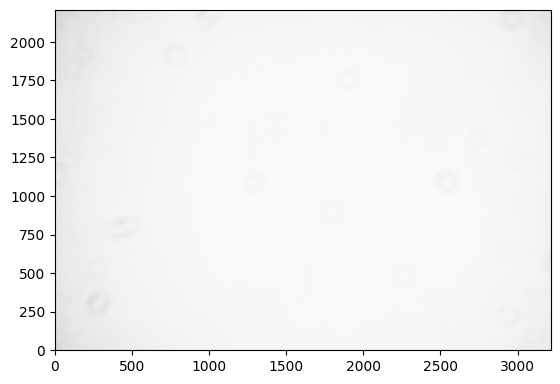

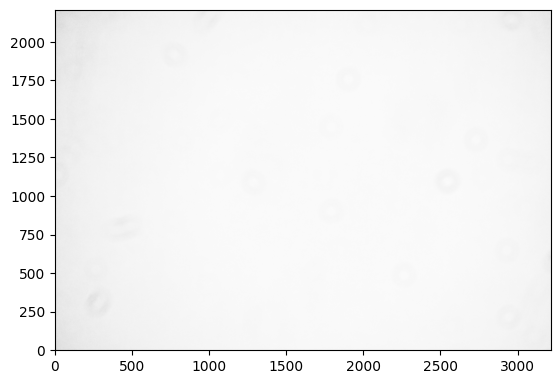

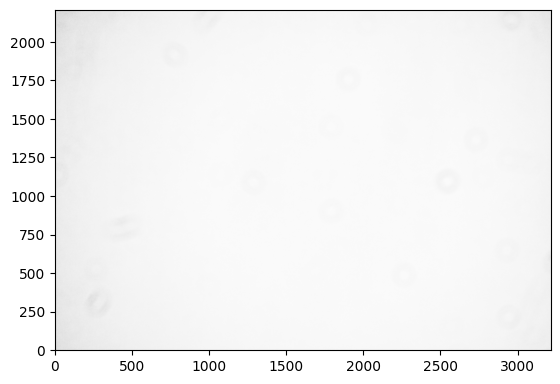

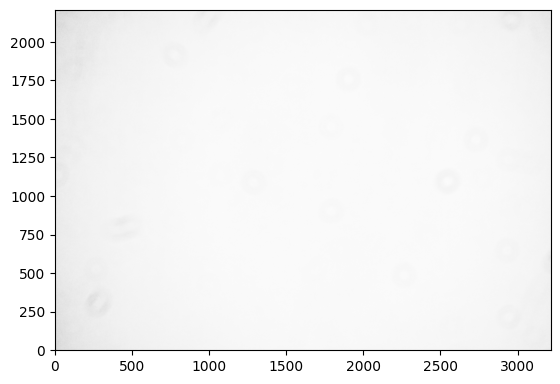

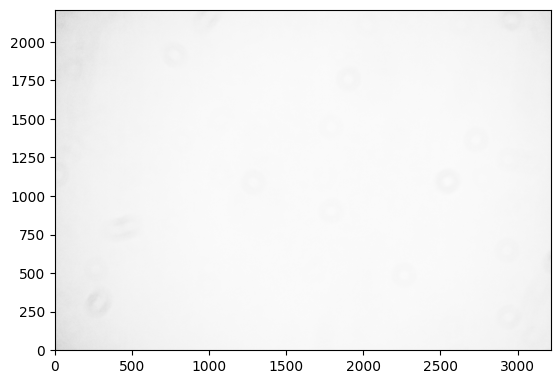

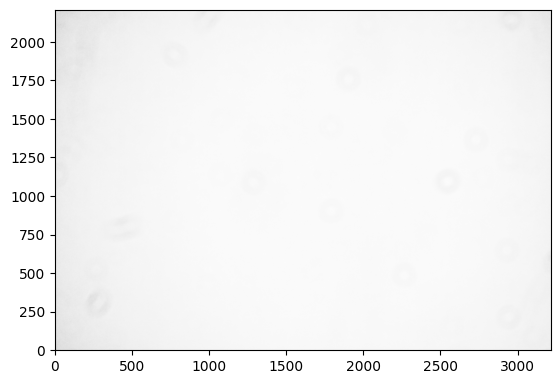

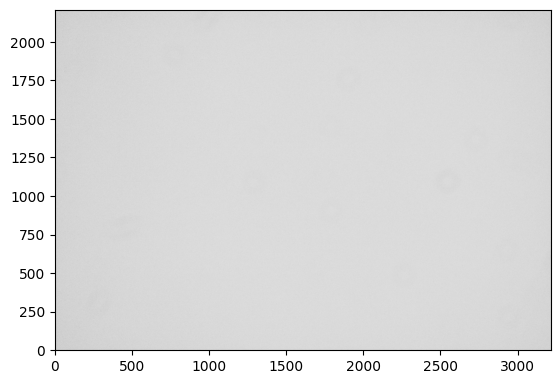

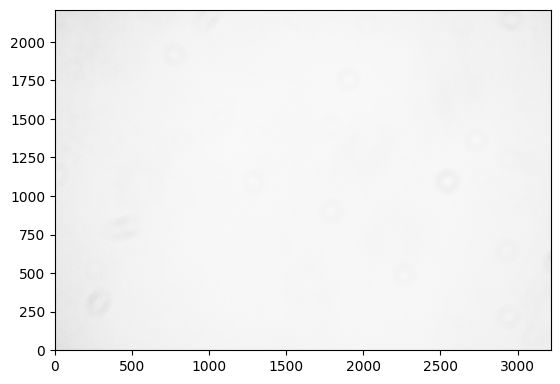

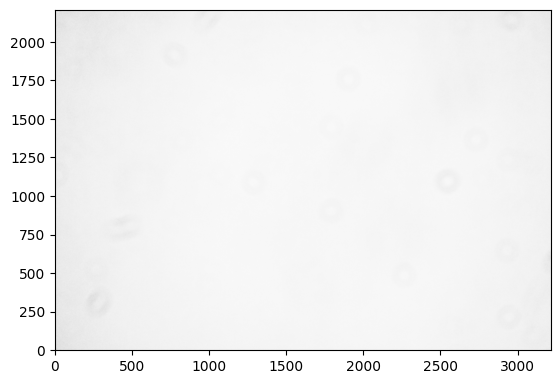

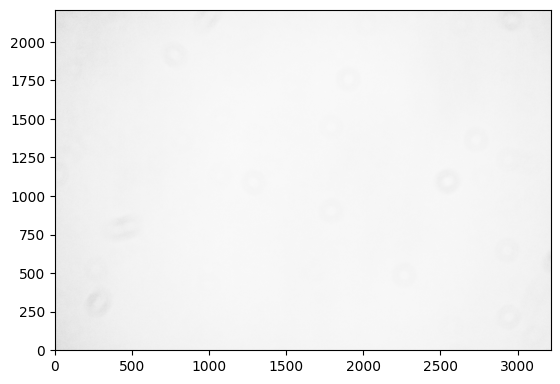

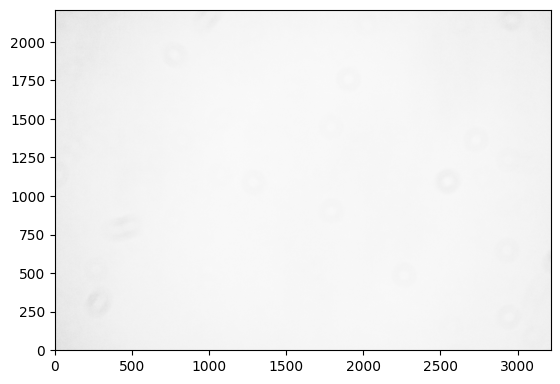

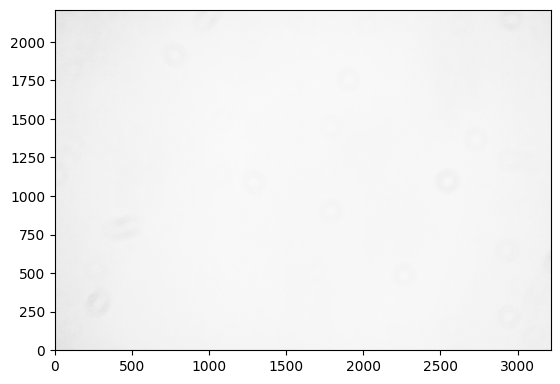

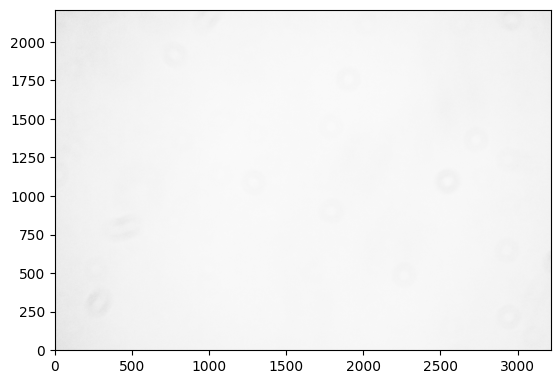

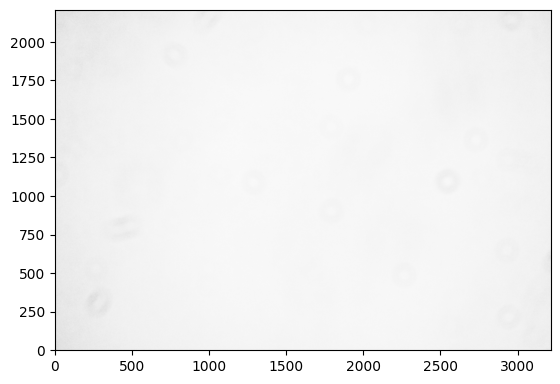

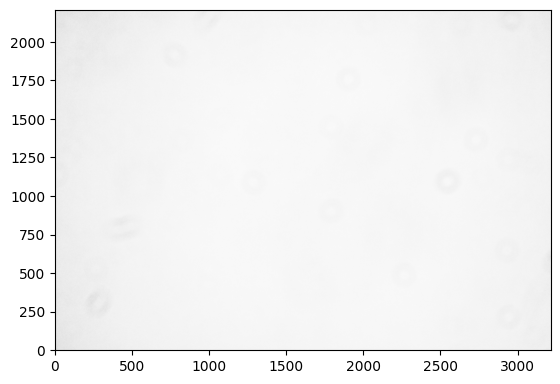

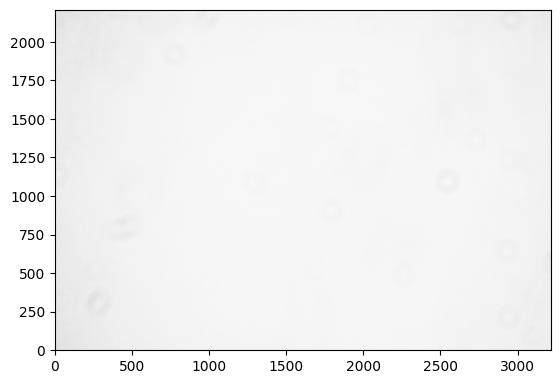

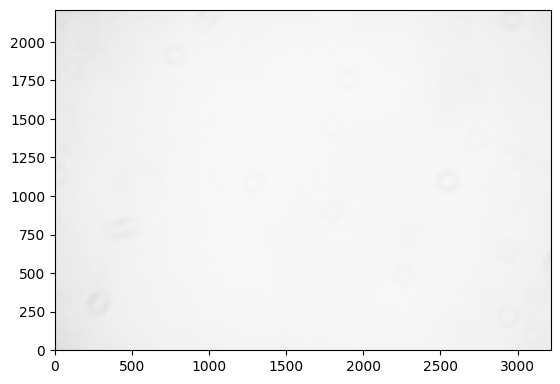

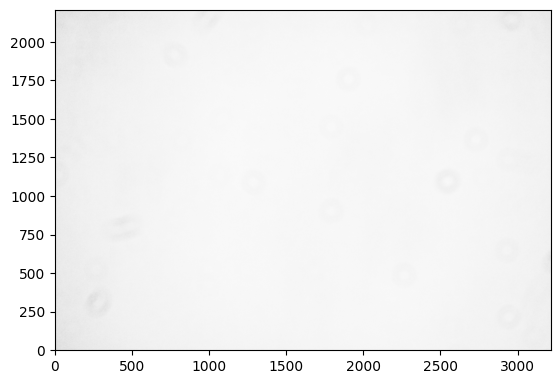

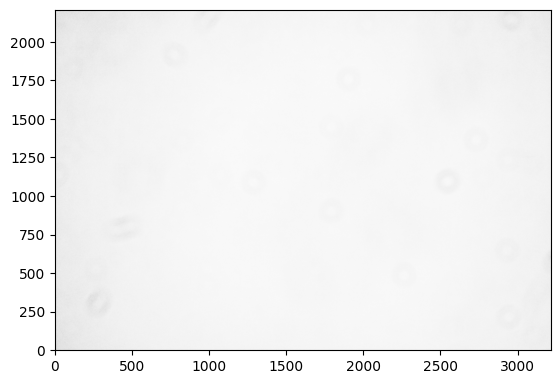

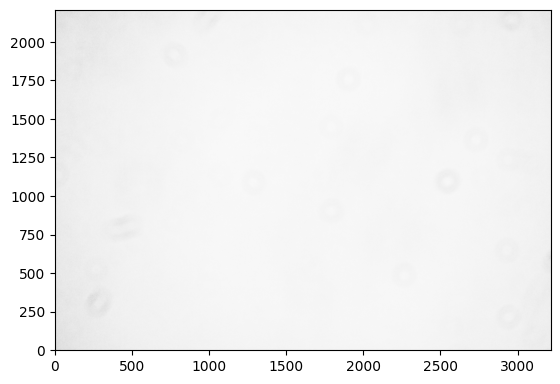

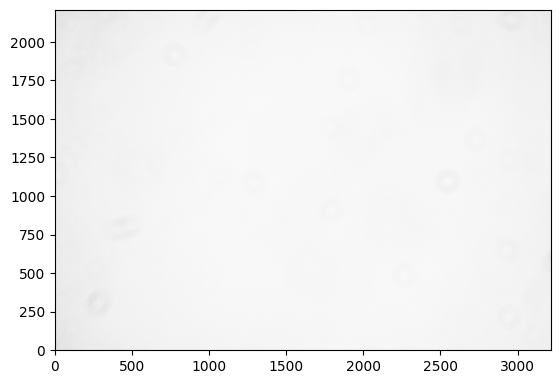

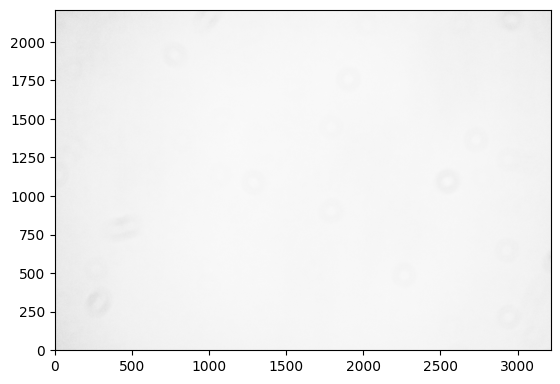

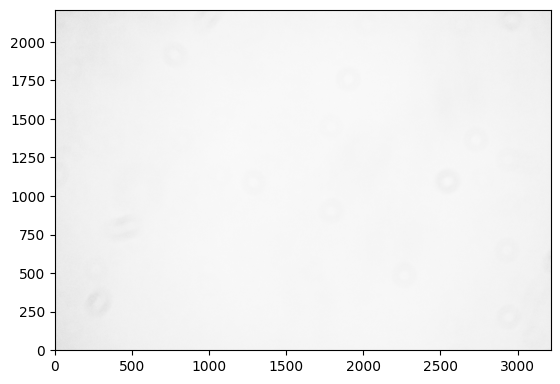

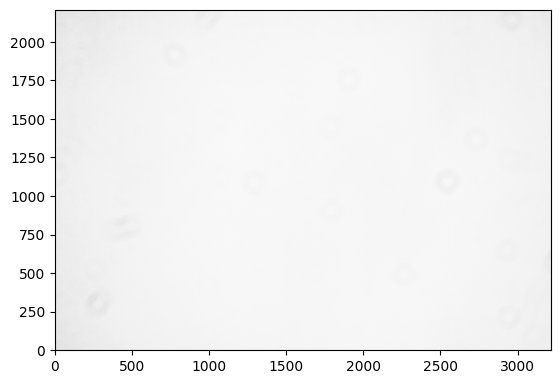

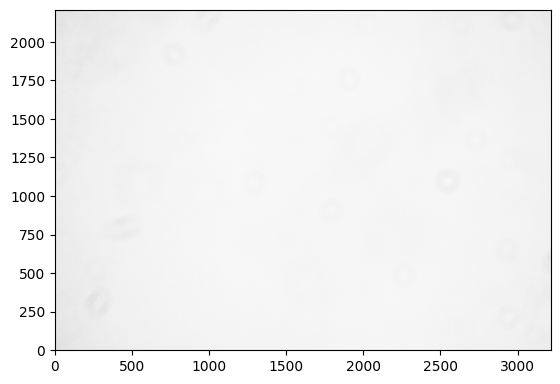

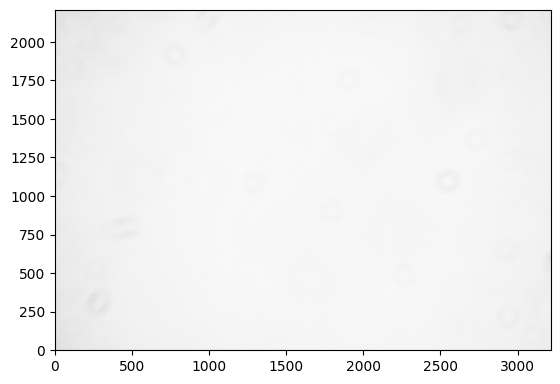

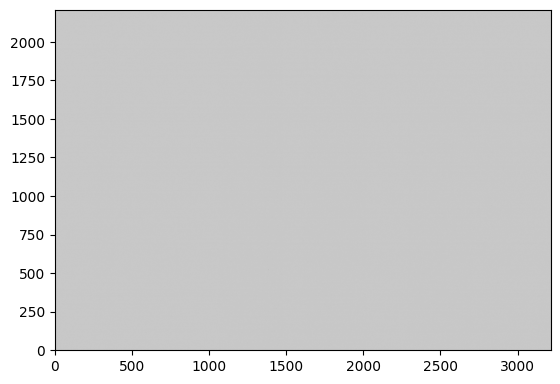

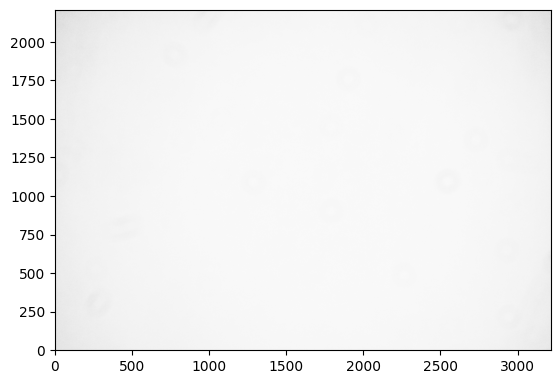

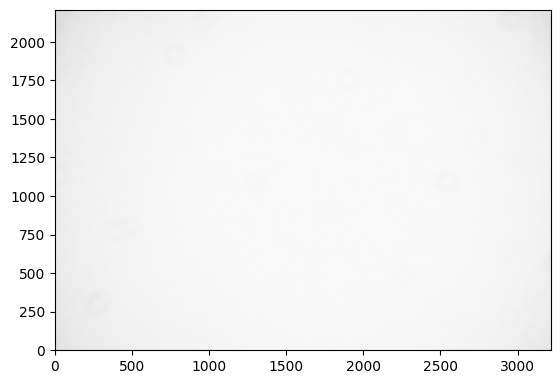

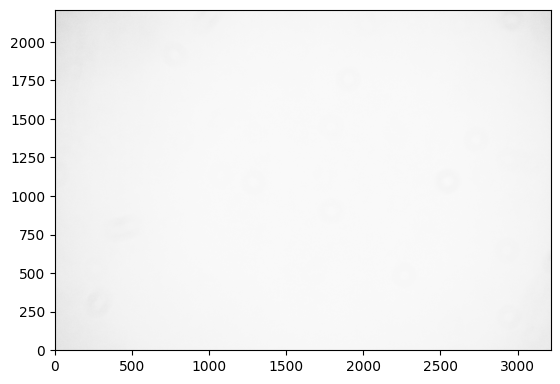

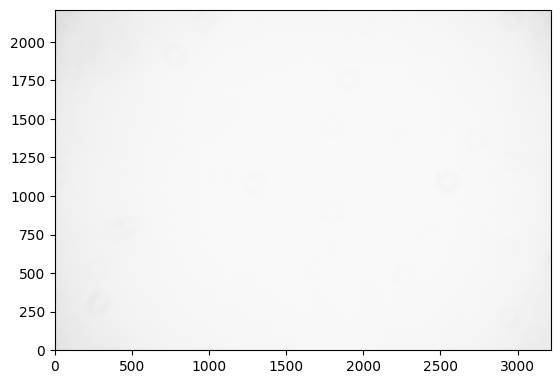

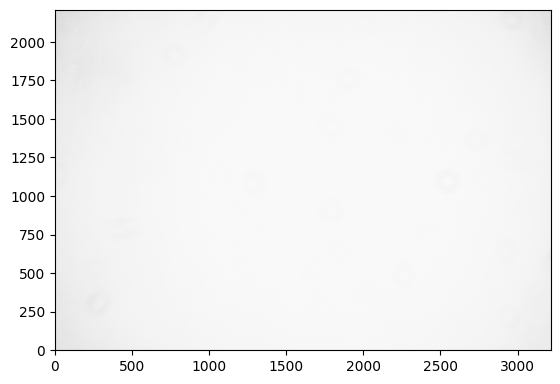

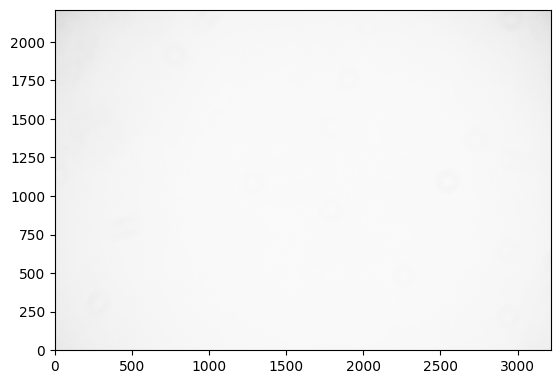

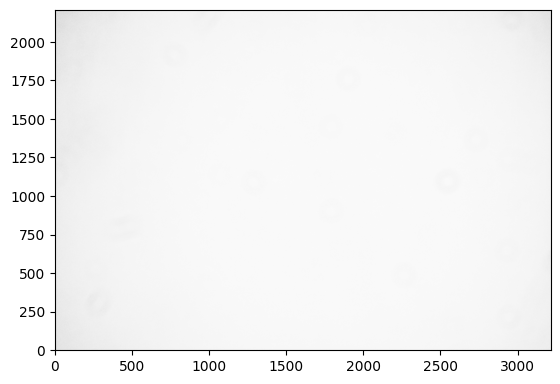

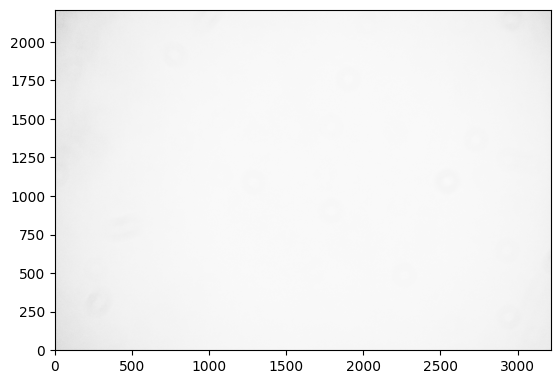

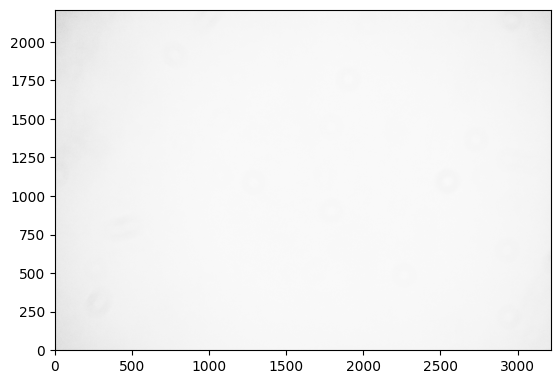

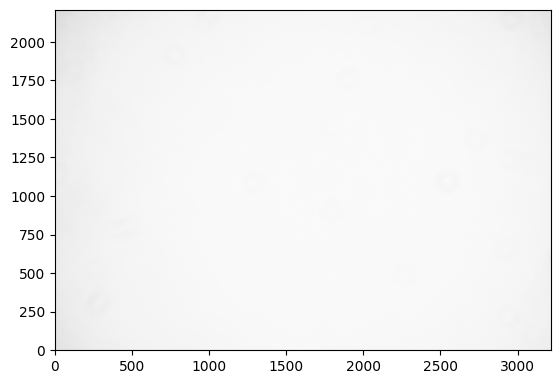

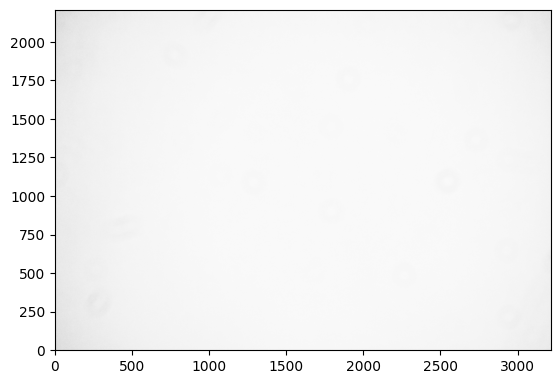

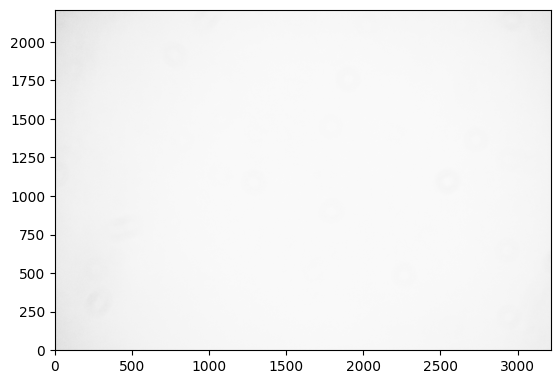

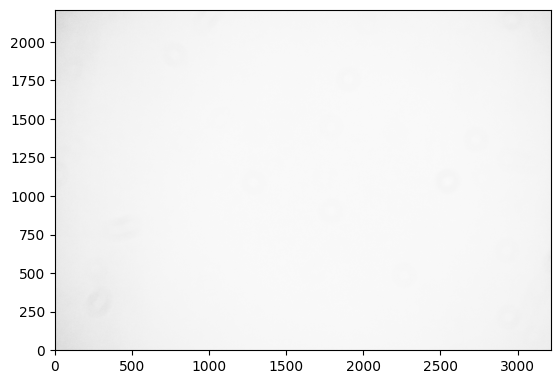

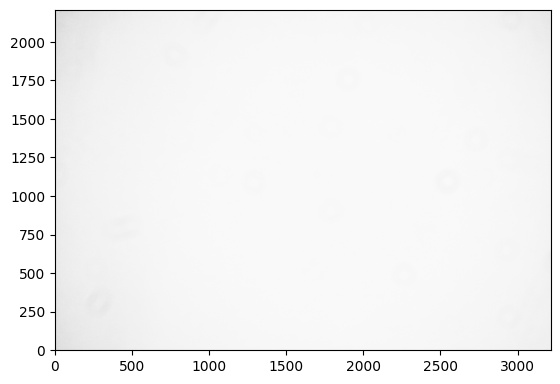

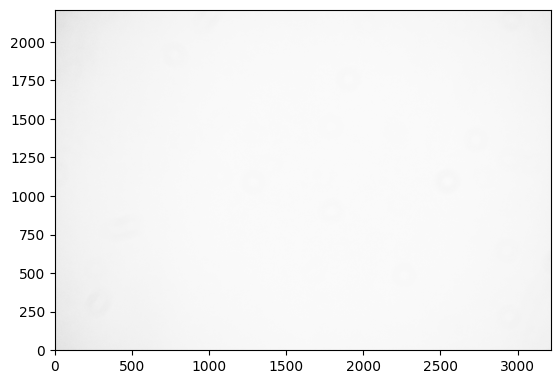

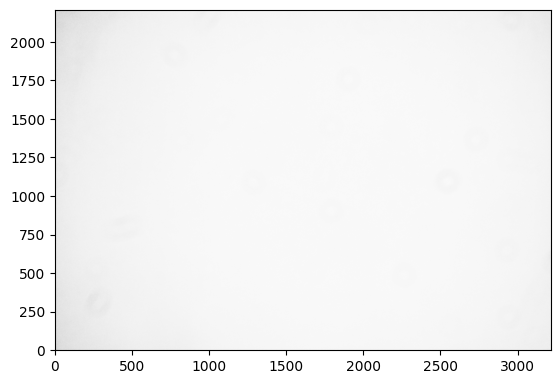

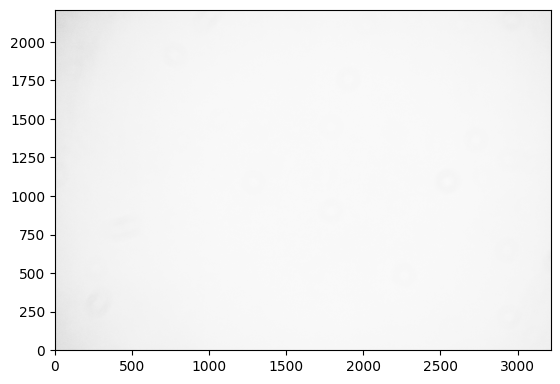

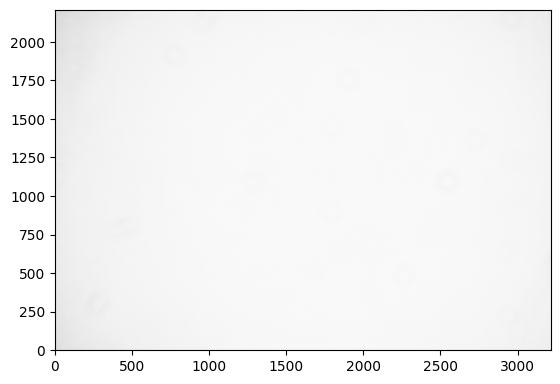

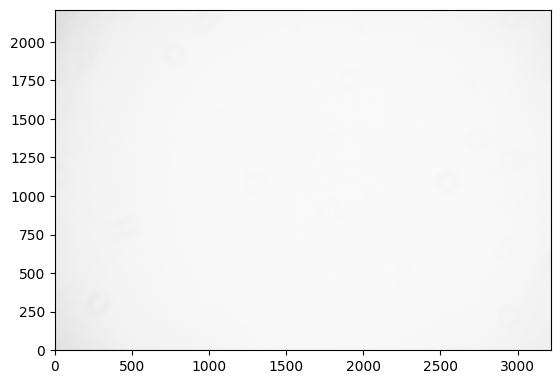

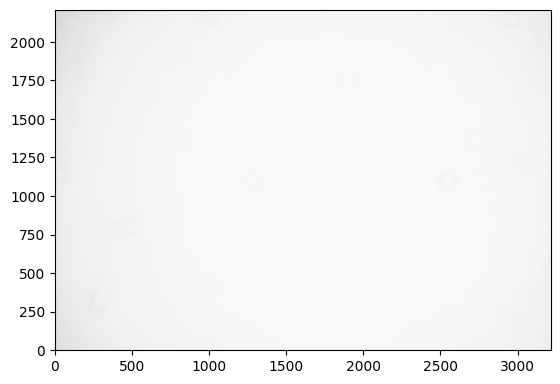

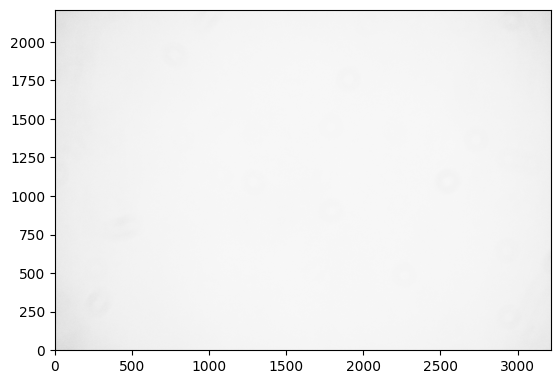

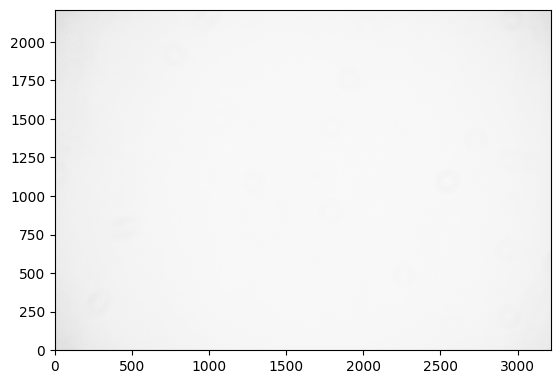

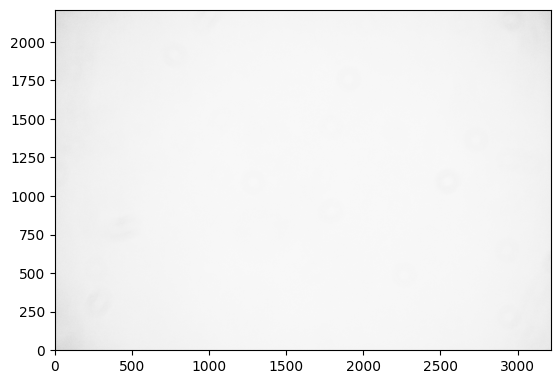

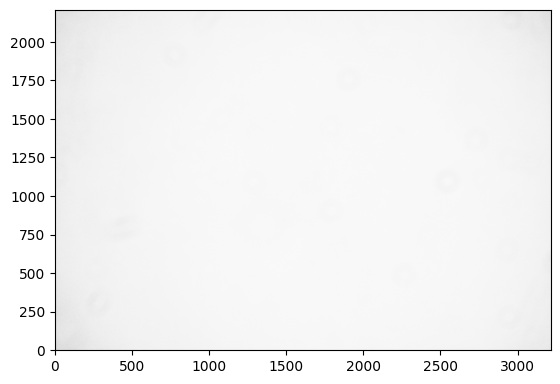

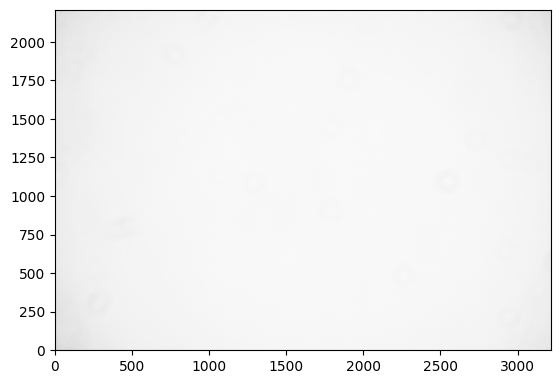

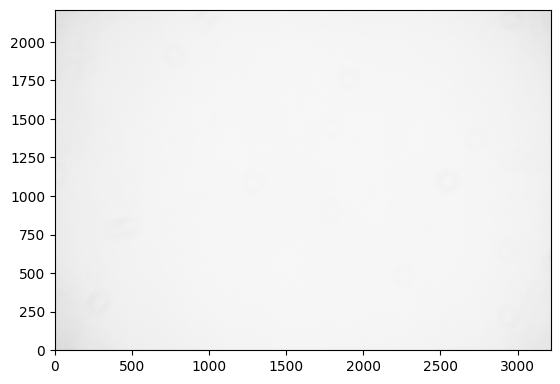

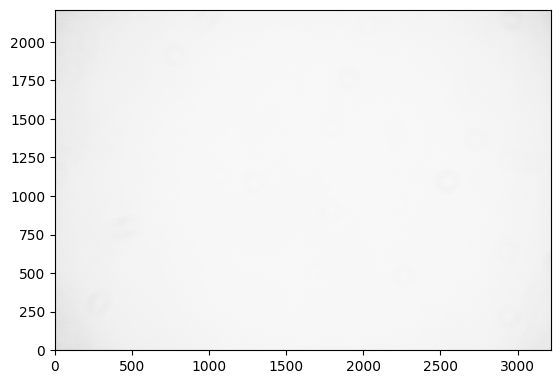

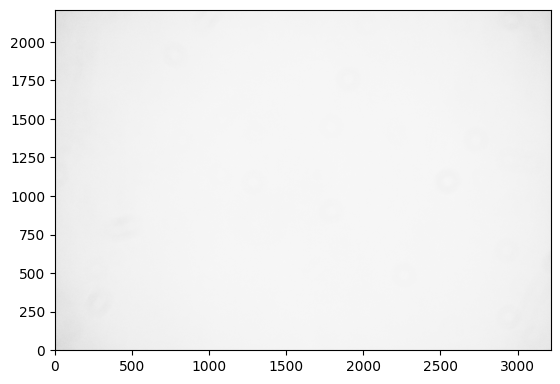

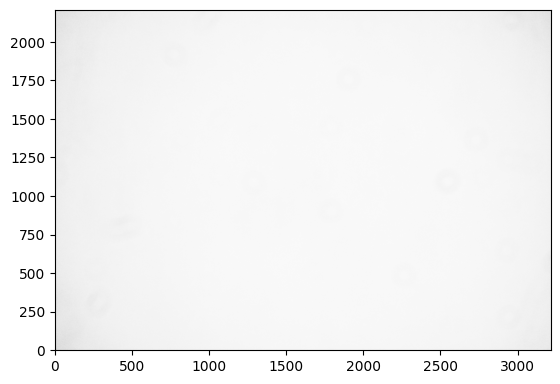

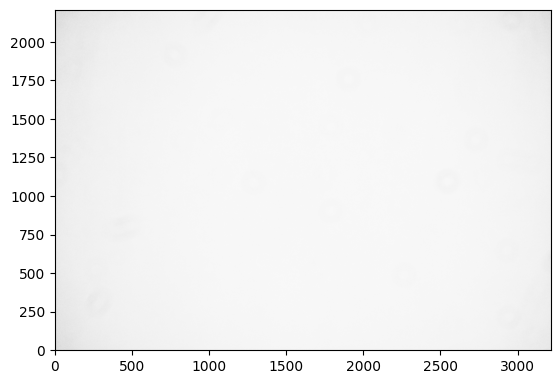

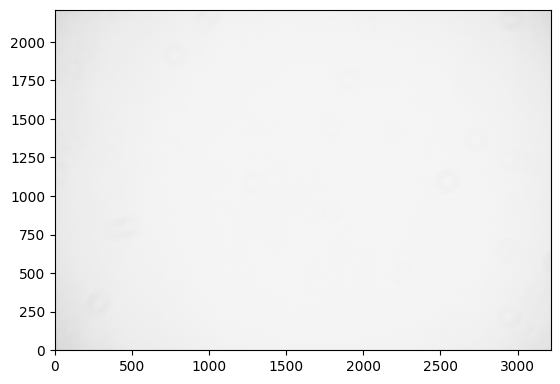

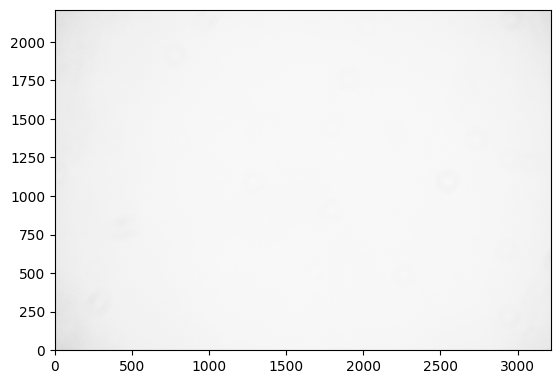

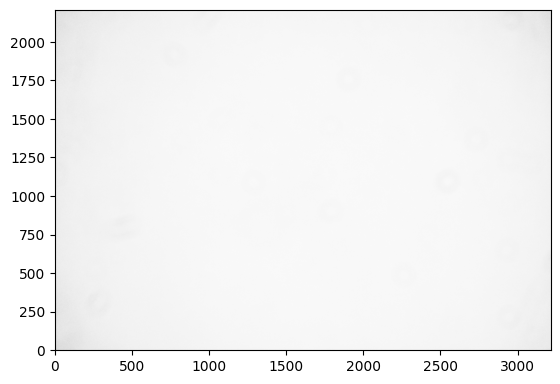

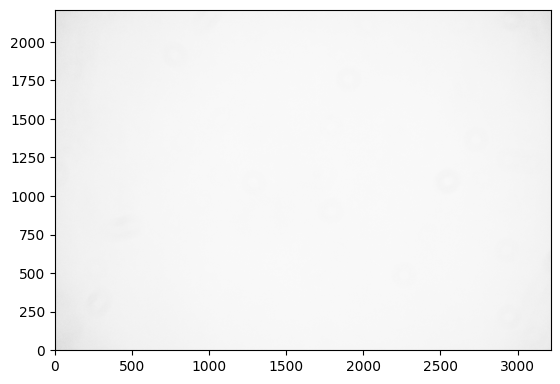

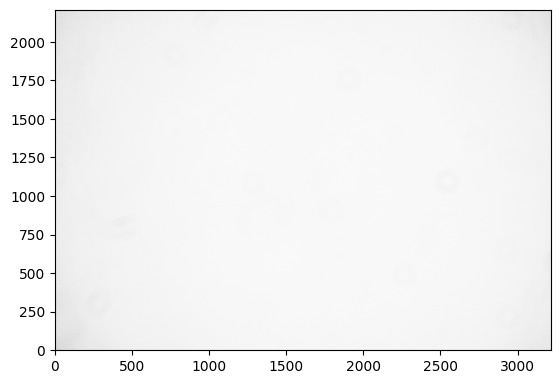

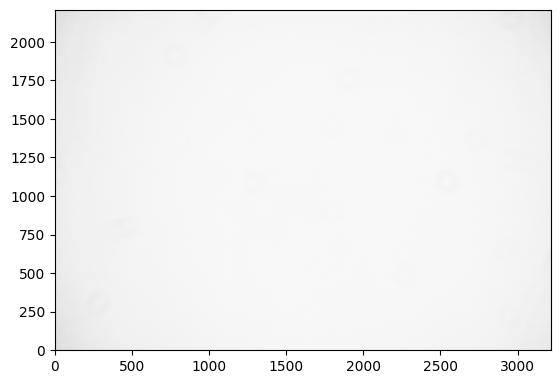

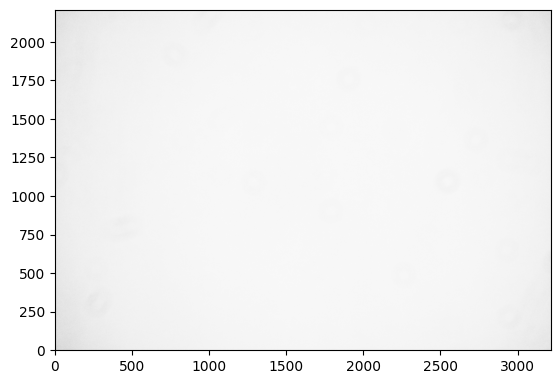

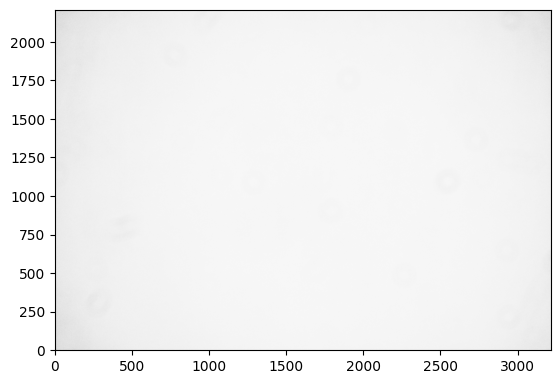

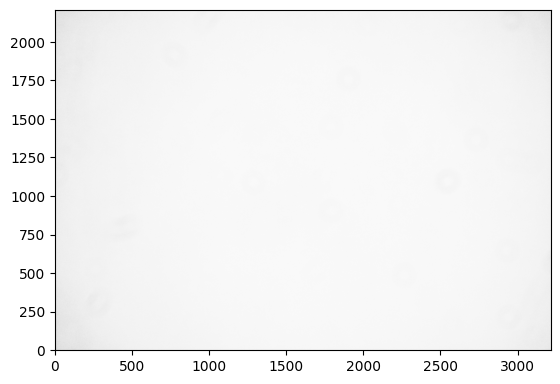

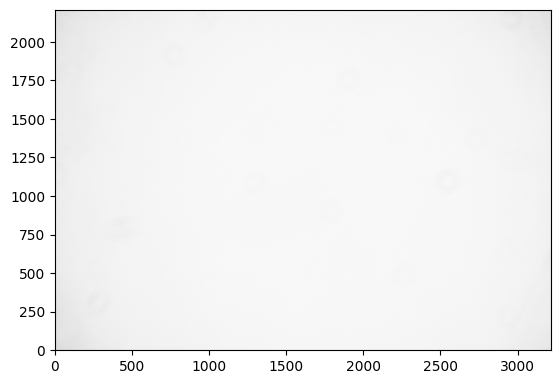

In [6]:
folders = ["L", "R", "G", "B"]
subfolders = ["darks", "lights", "biases", "flats"]
final_reduced_list = []

darks = im.get_files("./20250404/phot_HR1256_HR1262_p3s/L/darks/*D.fit", print_log=False)
masterdark = im.stack_files(darks)

bias = im.get_files("./20250404/phot_HR1256_HR1262_p3s/L/biases/*Bias.fit", print_log=False)
masterbias = im.stack_files(bias)

for folder in folders:
    my_reduced_list = []
    flat_files = im.get_files(f"./20250404/phot_HR1256_HR1262_p3s/{folder}/flats/*{folder}.fit", print_log=False)
    masterflat = im.stack_files(flat_files)
    light_files = im.get_files(f"./20250404/phot_HR1256_HR1262_p3s/{folder}/flats/*{folder}.fit", print_log=False)
    for i in range(len(light_files)):
        image = im.load_image(light_files[i], print_log=True)
        this_reduced_image = (image - masterdark) / (masterflat - masterbias)
        my_reduced_list.append(this_reduced_image)
    final_reduced_list.append(my_reduced_list)
    

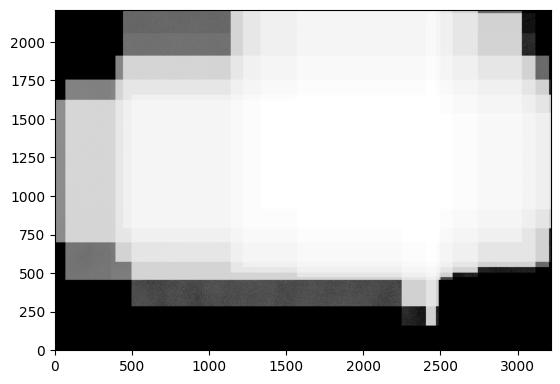

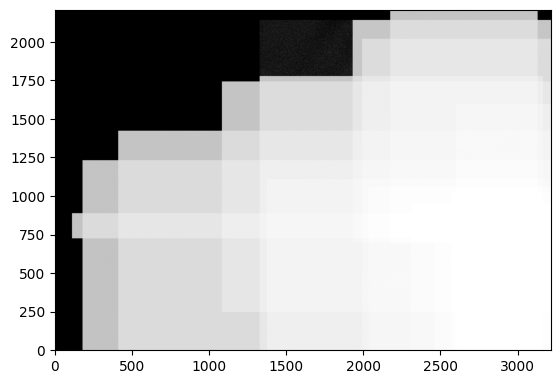

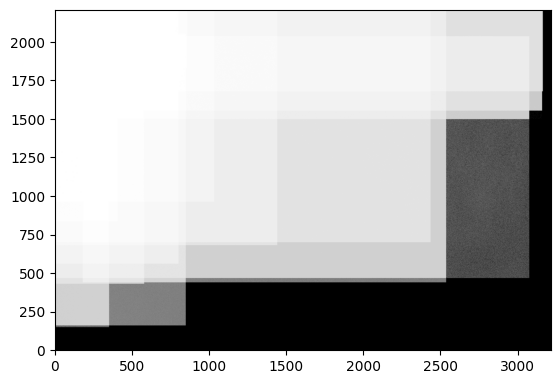

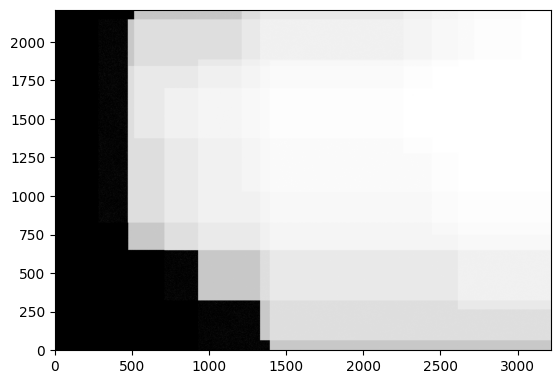

In [4]:
all_stacked = []
for f, folder in enumerate(folders):
    imgs = final_reduced_list[f]
    shifts = []
    first_position = im.find_star(imgs[0], search=100, print_log=False)
    shifts.append(first_position)
    for i in range(1, len(imgs)):
        this_position = im.find_star(imgs[i], search=100, print_log=False)
        shifts.append(this_position)

    shifts = np.array(shifts)
    shifts = shifts - shifts[0]
    stacked_image = im.stack(imgs, shifts=shifts)
    im.display(stacked_image, min_percent=20, max_percent=90)
    all_stacked.append(stacked_image)


In [ ]:
stars = im.get_files(